In [1]:
# ============================================================
#  环境配置
# ============================================================

# ── Colab 环境（取消注释后运行） ──
!pip install torch torchvision matplotlib numpy -U -q

# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# _install('torch==2.5.1')
# _install('matplotlib==3.9.4')
# _install('numpy==1.26.4')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 87.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


# BERT 从零到一：源代码实现 vs 简洁实现

基于论文 *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding* (Devlin et al., 2019)，
用 **MLM + NSP 预训练 → 情感分类微调** 演示 BERT 的核心架构。

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 手写 Multi-Head Attention / Encoder Block / MLM+NSP Head | `nn.TransformerEncoder` 替代手写编码器 |
| 代码量 | ~120 行 | ~50 行 |
| 适合场景 | 深入理解双向编码原理、面试准备 | 快速原型、工程落地 |
| 训练流程 | 预训练 (MLM+NSP) → 微调 (分类) | 同左 |

In [2]:
import random
import math
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. 数据准备

使用合成语料进行 **预训练**（MLM + NSP），然后在合成情感数据上 **微调**（二分类）。
所有数据内联生成，无需下载。

In [3]:
# ── 超参数（两种实现共用） ──
D_MODEL       = 128      # 模型维度（论文 768，缩小适配 CPU）
NUM_HEADS     = 4        # 注意力头数（论文 12）
NUM_LAYERS    = 2        # 编码器层数（论文 12）
D_FF          = 256      # FFN 隐藏维度（论文 3072）
MAX_SEQ_LEN   = 64       # 最大序列长度（论文 512）
DROPOUT       = 0.1
MASK_PROB     = 0.15     # MLM 遮盖比例

PRETRAIN_LR     = 1e-3
FINETUNE_LR     = 2e-4
PRETRAIN_EPOCHS = 30     # CPU 友好
FINETUNE_EPOCHS = 20
BATCH_SIZE      = 32
NUM_PRETRAIN    = 1000   # 预训练样本数

In [4]:
# ── 合成语料库（30 篇"文档"，每篇 3 句） ──
documents = [
    ['the cat sat on the warm mat', 'it was a very sunny day outside', 'the dog played happily in the park'],
    ['i enjoy reading books every day', 'science fiction is my favorite genre', 'i finished reading two books this week'],
    ['the weather was cold and windy', 'snow covered the ground everywhere', 'children built a big snowman together'],
    ['she went to the store yesterday', 'she bought some fresh fruit and bread', 'the apples were very sweet today'],
    ['he studied math and science hard', 'the exam was quite difficult this time', 'he passed with a very good grade'],
    ['the flowers bloomed in the garden', 'birds sang in the tall green trees', 'it was a beautiful morning outside'],
    ['the team won the big game tonight', 'fans cheered very loud in the stadium', 'it was an exciting close match'],
    ['cooking is a great hobby for all', 'she made a delicious chocolate cake', 'everyone loved the food she prepared'],
    ['the train arrived at the station', 'passengers got on the train quickly', 'the journey took about two hours'],
    ['the book was very interesting indeed', 'the story had many unexpected twists', 'i could not stop reading it'],
    ['the ocean was calm and peaceful', 'we watched the sunset on the beach', 'the sky turned orange and pink'],
    ['he played the guitar very well', 'music filled the entire room softly', 'everyone listened quietly and enjoyed'],
    ['the garden looked beautiful in summer', 'roses and tulips were blooming nicely', 'butterflies danced gracefully in air'],
    ['she ran five miles every morning', 'exercise is important for good health', 'she felt great and strong afterwards'],
    ['the coffee shop was warm and cozy', 'i ordered a large cup of coffee', 'the barista made it perfectly today'],
    ['the library was quiet and peaceful', 'students studied hard for their exams', 'books lined every shelf very neatly'],
    ['the river flowed gently downstream', 'fish swam in the clear blue water', 'it was a relaxing and calm place'],
    ['the night sky was clear tonight', 'stars twinkled brightly above us all', 'the moon was bright and full'],
    ['the puppy was playful and cute', 'it chased its own tail all around', 'we all laughed watching it play'],
    ['the market was busy and crowded', 'vendors sold fresh vegetables and fruit', 'the smell of spices filled the air'],
    ['the mountain trail was steep rocky', 'hikers climbed slowly but steadily up', 'the view from top was breathtaking'],
    ['the concert was loud and exciting', 'the band played their best songs', 'the crowd danced and sang along'],
    ['the baby slept peacefully in crib', 'soft music played gently in room', 'the mother watched with warm smile'],
    ['the airplane flew high above clouds', 'passengers looked out the small windows', 'the flight landed safely at airport'],
    ['the painting hung on gallery wall', 'visitors admired the colorful artwork', 'the artist was famous worldwide'],
    ['the pizza was hot freshly baked', 'we shared it with all our friends', 'everyone agreed it was delicious'],
    ['the program worked perfectly fine', 'the developer fixed all bugs quickly', 'the software was ready for release'],
    ['the sunset was magnificent today', 'colors painted the sky warm shades', 'we took many photographs together'],
    ['the classroom was bright organized', 'teacher explained the lesson clearly', 'students asked interesting questions'],
    ['the hospital was clean and modern', 'doctors and nurses worked hard daily', 'patients received excellent care'],
]

# ── 情感分类数据 ──
positive_texts = [
    'this movie is absolutely wonderful', 'i really enjoyed watching this film',
    'the acting was outstanding and brilliant', 'a beautiful and captivating story',
    'excellent direction and wonderful work', 'i loved every moment of this movie',
    'the best film i have seen all year', 'highly recommend this to everyone',
    'a fantastic movie with great characters', 'such a heartwarming inspiring experience',
    'the plot was engaging and exciting', 'brilliant writing and superb acting',
    'a true masterpiece of modern cinema', 'the music was beautiful and touching',
    'every scene was perfectly crafted', 'an incredible journey start to finish',
    'the actors delivered amazing performances', 'a delightful and charming movie',
    'the story was captivating throughout', 'one of the greatest films ever made',
    'stunning visuals and gorgeous scenes', 'a perfect blend of humor and drama',
    'i would happily watch this again', 'the ending was satisfying and perfect',
    'a wonderful experience for the family', 'superb cinematography and storytelling',
    'the characters were deep and relatable', 'a refreshing and original film',
    'the pacing was perfect throughout', 'an emotional and powerful experience',
    'creative original work by director', 'the humor was natural and funny',
    'an uplifting hopeful story about life', 'the film exceeded my expectations',
    'incredible effects and amazing visuals', 'the screenplay was clever and witty',
    'a joyful celebration of happiness', 'the director did a brilliant job',
    'this is a must see film', 'absolutely loved this great movie',
]

negative_texts = [
    'this movie is absolutely terrible', 'i really hated watching this film',
    'the acting was awful and boring', 'a horrible and ugly story overall',
    'terrible direction and weak work', 'i disliked every moment of this movie',
    'the worst film i have seen all year', 'do not recommend this to anyone',
    'a horrible movie with weak characters', 'such a boring depressing experience',
    'the plot was confusing and dull', 'poor writing and mediocre acting',
    'a complete disaster of modern cinema', 'the music was annoying and loud',
    'every scene was poorly executed', 'a painful journey start to finish',
    'the actors delivered weak performances', 'a boring and forgettable movie',
    'the story was predictable throughout', 'one of the worst films ever made',
    'ugly visuals and cheap scenes', 'a terrible mix of nonsense and drama',
    'i would never watch this again', 'the ending was disappointing and bad',
    'a complete waste of time overall', 'terrible cinematography and storytelling',
    'the characters were flat and boring', 'a stale and unoriginal film',
    'the pacing was slow and boring', 'an empty and meaningless experience',
    'lazy unoriginal work by director', 'the humor was forced and unfunny',
    'a depressing hopeless story overall', 'the film failed my expectations',
    'horrible effects and ugly visuals', 'the screenplay was dull and weak',
    'a joyless waste of time money', 'the director did a terrible job',
    'this is a must avoid film', 'absolutely hated this bad movie',
]

# ── 简单词级分词器 ──
class SimpleTokenizer:
    PAD, UNK, CLS, SEP, MASK = 0, 1, 2, 3, 4

    def __init__(self):
        self.word2idx = {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3, '[MASK]': 4}
        self.idx2word = {v: k for k, v in self.word2idx.items()}

    @property
    def vocab_size(self):
        return len(self.word2idx)

    def build_vocab(self, sentences):
        for sent in sentences:
            for w in sent.lower().split():
                if w not in self.word2idx:
                    idx = len(self.word2idx)
                    self.word2idx[w] = idx
                    self.idx2word[idx] = w

    def encode(self, text):
        return [self.word2idx.get(w, self.UNK) for w in text.lower().split()]

    def decode(self, ids):
        return ' '.join(self.idx2word.get(i, '[UNK]') for i in ids)

# 构建词表（预训练 + 情感数据共用）
tokenizer = SimpleTokenizer()
all_sents = [s for doc in documents for s in doc] + positive_texts + negative_texts
tokenizer.build_vocab(all_sents)
VOCAB_SIZE = tokenizer.vocab_size
print(f'词表大小: {VOCAB_SIZE}')

词表大小: 456


In [5]:
# ── 预训练数据集 (MLM + NSP) ──
class BERTPretrainDataset(Dataset):
    """生成 BERT 预训练样本：MLM 遮盖 + NSP 标签"""

    def __init__(self, documents, tokenizer, max_len, num_samples, mask_prob=0.15):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.mask_prob = mask_prob
        self.samples = []

        for _ in range(num_samples):
            doc_idx = random.randint(0, len(documents) - 1)
            doc = documents[doc_idx]
            sent_idx = random.randint(0, len(doc) - 2)
            sent_a = doc[sent_idx]

            # 50% IsNext, 50% NotNext
            if random.random() > 0.5:
                sent_b = doc[sent_idx + 1]
                is_next = 1
            else:
                rand_doc = documents[random.randint(0, len(documents) - 1)]
                sent_b = rand_doc[random.randint(0, len(rand_doc) - 1)]
                is_next = 0
            self.samples.append((sent_a, sent_b, is_next))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sent_a, sent_b, is_next = self.samples[idx]
        tok_a = self.tokenizer.encode(sent_a)
        tok_b = self.tokenizer.encode(sent_b)

        # 截断以适配 max_len: [CLS] A [SEP] B [SEP]
        max_tok = self.max_len - 3
        if len(tok_a) + len(tok_b) > max_tok:
            half = max_tok // 2
            tok_a = tok_a[:half]
            tok_b = tok_b[:max_tok - half]

        tokens = [self.tokenizer.CLS] + tok_a + [self.tokenizer.SEP] + tok_b + [self.tokenizer.SEP]
        segments = [0] * (len(tok_a) + 2) + [1] * (len(tok_b) + 1)

        # ── MLM: 80% [MASK] / 10% 随机词 / 10% 保持 ──
        mlm_labels = [-100] * len(tokens)
        maskable = [i for i in range(len(tokens))
                     if tokens[i] not in (self.tokenizer.PAD, self.tokenizer.CLS, self.tokenizer.SEP)]
        num_mask = max(1, int(len(maskable) * self.mask_prob))
        chosen = random.sample(maskable, min(num_mask, len(maskable)))

        for i in chosen:
            mlm_labels[i] = tokens[i]
            r = random.random()
            if r < 0.8:
                tokens[i] = self.tokenizer.MASK
            elif r < 0.9:
                tokens[i] = random.randint(5, self.tokenizer.vocab_size - 1)
            # else: 保持原词

        # 填充
        pad_len = self.max_len - len(tokens)
        attn_mask = [1] * len(tokens) + [0] * pad_len
        tokens   += [self.tokenizer.PAD] * pad_len
        segments += [0] * pad_len
        mlm_labels += [-100] * pad_len

        return {
            'input_ids':     torch.tensor(tokens, dtype=torch.long),
            'segment_ids':   torch.tensor(segments, dtype=torch.long),
            'attention_mask': torch.tensor(attn_mask, dtype=torch.long),
            'mlm_labels':    torch.tensor(mlm_labels, dtype=torch.long),
            'nsp_label':     torch.tensor(is_next, dtype=torch.long),
        }


# ── 情感分类数据集 ──
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        toks = self.tokenizer.encode(self.texts[idx])
        toks = [self.tokenizer.CLS] + toks[:self.max_len - 2] + [self.tokenizer.SEP]
        segs = [0] * len(toks)
        pad_len = self.max_len - len(toks)
        attn = [1] * len(toks) + [0] * pad_len
        toks += [self.tokenizer.PAD] * pad_len
        segs += [0] * pad_len
        return {
            'input_ids':      torch.tensor(toks, dtype=torch.long),
            'segment_ids':    torch.tensor(segs, dtype=torch.long),
            'attention_mask': torch.tensor(attn, dtype=torch.long),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [6]:
# ── 构建 DataLoader ──
pretrain_ds = BERTPretrainDataset(documents, tokenizer, MAX_SEQ_LEN, NUM_PRETRAIN, MASK_PROB)
pretrain_loader = DataLoader(pretrain_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# 情感数据: 前 32 条为训练集，后 8 条为测试集（正负各半）
train_texts  = positive_texts[:32] + negative_texts[:32]
train_labels = [1] * 32 + [0] * 32
test_texts   = positive_texts[32:] + negative_texts[32:]
test_labels  = [1] * (len(positive_texts) - 32) + [0] * (len(negative_texts) - 32)

train_ds = SentimentDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LEN)
test_ds  = SentimentDataset(test_texts, test_labels, tokenizer, MAX_SEQ_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# 验证形状
batch = next(iter(pretrain_loader))
print('预训练 batch:')
for k, v in batch.items():
    print(f'  {k:16s}: {v.shape}')

batch_ft = next(iter(train_loader))
print('\n微调 batch:')
for k, v in batch_ft.items():
    print(f'  {k:16s}: {v.shape}')

预训练 batch:
  input_ids       : torch.Size([32, 64])
  segment_ids     : torch.Size([32, 64])
  attention_mask  : torch.Size([32, 64])
  mlm_labels      : torch.Size([32, 64])
  nsp_label       : torch.Size([32])

微调 batch:
  input_ids       : torch.Size([32, 64])
  segment_ids     : torch.Size([32, 64])
  attention_mask  : torch.Size([32, 64])
  label           : torch.Size([32])


## 2. 共享组件

预训练与微调的训练函数、绘图工具。

In [7]:
def pretrain_epoch(model, loader, optimizer, device):
    """一个 epoch 的预训练（MLM + NSP）"""
    model.train()
    mlm_crit = nn.CrossEntropyLoss(ignore_index=-100)
    nsp_crit = nn.CrossEntropyLoss()
    total_loss, n = 0.0, 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        segs = batch['segment_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        mlm_lbl = batch['mlm_labels'].to(device)
        nsp_lbl = batch['nsp_label'].to(device)

        mlm_logits, nsp_logits = model(ids, segs, mask)
        loss = mlm_crit(mlm_logits.view(-1, mlm_logits.size(-1)), mlm_lbl.view(-1)) \
             + nsp_crit(nsp_logits, nsp_lbl)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += 1
    return total_loss / n


def finetune_epoch(model, loader, optimizer, device):
    """一个 epoch 的微调（分类）"""
    model.train()
    crit = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        segs = batch['segment_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        logits = model(ids, segs, mask)
        loss = crit(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    """评估分类准确率"""
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        segs = batch['segment_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        logits = model(ids, segs, mask)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return correct / total


def plot_losses(losses, title):
    plt.figure(figsize=(8, 3))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 预训练 vs 微调（训练 vs 推理）的区别

| 阶段 | 输入格式 | 训练目标 | 输出 |
|------|---------|---------|------|
| **预训练** | `[CLS] A [SEP] B [SEP]`，15% token 被遮盖 | MLM: 预测被遮盖 token + NSP: 判断 B 是否为 A 下一句 | MLM logits + NSP logits |
| **微调** | `[CLS] sentence [SEP]`，无遮盖 | 分类: `[CLS]` 输出 → 类别 | 分类 logits |
| **推理** | 同微调 | 无反向传播，`torch.no_grad()` | 预测标签 |

关键：预训练和微调**共享 BERT 编码器**，仅更换任务头（MLM/NSP Head → 分类 Head）。

---

## 3. 实现 A — 源代码实现

逐组件手写：输入嵌入 → Multi-Head Self-Attention → Encoder Block → BERT 编码器 → 任务头。

### 输入表示 (Input Representation)

BERT 的输入向量由三部分**相加**得到：

$$\text{Input} = \text{TokenEmb}(x) + \text{SegmentEmb}(s) + \text{PositionEmb}(p)$$

- **Token Embedding**: WordPiece 分词后的词嵌入，$(\text{batch}, \text{seq}) \to (\text{batch}, \text{seq}, d)$
- **Segment Embedding**: 区分句子 A/B 的学习向量 $E_A, E_B$
- **Position Embedding**: **学习**得到的位置编码（非固定三角函数），最大长度 512

相加后经过 LayerNorm + Dropout。

In [8]:
class BERTEmbedding(nn.Module):
    """Token + Segment + Position 嵌入，三者相加"""

    def __init__(self, vocab_size, d_model, max_len, dropout):
        super().__init__()
        self.token_embed    = nn.Embedding(vocab_size, d_model)  # (vocab) -> (d_model)
        self.segment_embed  = nn.Embedding(2, d_model)           # 0=句A, 1=句B
        self.position_embed = nn.Embedding(max_len, d_model)     # 学习的位置编码
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, segment_ids):
        # input_ids: (batch, seq), segment_ids: (batch, seq)
        seq_len = input_ids.size(1)
        pos_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)  # (1, seq)

        x = self.token_embed(input_ids)      # (batch, seq, d_model)
        x = x + self.segment_embed(segment_ids)  # + segment
        x = x + self.position_embed(pos_ids)     # + position
        return self.dropout(self.norm(x))         # (batch, seq, d_model)

### Multi-Head Self-Attention

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

BERT 使用 **Self-Attention**：$Q = K = V = x$（同一序列的不同位置相互关注），实现**双向**上下文编码。

- 输入: $(\text{batch}, \text{seq}, d)$ → 输出: $(\text{batch}, \text{seq}, d)$
- `attention_mask` 阻止对 `[PAD]` 位置的关注

### Transformer Encoder Block

$$\text{Block}(x) = \text{LN}(x + \text{FFN}(\text{LN}(x + \text{MHA}(x))))$$

其中 FFN 使用 **GELU** 激活（而非 ReLU）：

$$\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        B, S, _ = x.shape
        # 线性投影 + reshape: (B, S, d) -> (B, h, S, d_k)
        Q = self.W_q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled Dot-Product: (B, h, S, S)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if attention_mask is not None:
            # attention_mask: (B, S) -> (B, 1, 1, S)
            mask = attention_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_w = self.dropout(torch.softmax(scores, dim=-1))  # (B, h, S, S)
        ctx = torch.matmul(attn_w, V)                         # (B, h, S, d_k)
        ctx = ctx.transpose(1, 2).contiguous().view(B, S, -1) # (B, S, d)
        return self.W_o(ctx), attn_w


class TransformerBlock(nn.Module):
    """Post-LN Encoder Block: MHA -> Add&Norm -> FFN -> Add&Norm"""

    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),                    # BERT 使用 GELU
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, attention_mask=None):
        # x: (B, S, d)
        attn_out, attn_w = self.attn(x, attention_mask)
        x = self.norm1(x + attn_out)       # Add & Norm
        x = self.norm2(x + self.ffn(x))    # Add & Norm
        return x, attn_w

### 完整 BERT 模型 + 任务头

BERT 编码器是共享骨干，不同训练阶段替换不同的任务头：

| 阶段 | 任务头 | 输入/输出 |
|------|-------|----------|
| 预训练 | **MLM Head** (所有位置 → vocab logits) + **NSP Head** (`[CLS]` → 2-class) | 总损失 = MLM + NSP |
| 微调 | **分类 Head** (`[CLS]` → num_classes) | 分类交叉熵 |

In [10]:
class BERTScratch(nn.Module):
    """BERT 编码器（共享骨干）"""

    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout):
        super().__init__()
        self.d_model = d_model
        self.embedding = BERTEmbedding(vocab_size, d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self._attn_weights = None  # 用于可视化

    def encode(self, input_ids, segment_ids, attention_mask):
        # input_ids/segment_ids: (B, S), attention_mask: (B, S)
        x = self.embedding(input_ids, segment_ids)  # (B, S, d_model)
        all_attn = []
        for layer in self.layers:
            x, attn_w = layer(x, attention_mask)     # (B, S, d_model)
            all_attn.append(attn_w)
        self._attn_weights = all_attn
        return x                                     # (B, S, d_model)


class BERTForPretraining(nn.Module):
    """预训练：MLM + NSP 双任务头"""

    def __init__(self, bert, vocab_size):
        super().__init__()
        self.bert = bert
        d = bert.d_model
        self.mlm_head = nn.Sequential(
            nn.Linear(d, d), nn.GELU(), nn.LayerNorm(d),
            nn.Linear(d, vocab_size),     # (B, S, vocab)
        )
        self.nsp_head = nn.Linear(d, 2)  # (B, 2)

    def forward(self, input_ids, segment_ids, attention_mask):
        h = self.bert.encode(input_ids, segment_ids, attention_mask)  # (B, S, d)
        return self.mlm_head(h), self.nsp_head(h[:, 0])


class BERTClassifier(nn.Module):
    """微调：[CLS] -> 分类"""

    def __init__(self, bert, num_classes):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(bert.d_model, num_classes)

    def forward(self, input_ids, segment_ids, attention_mask):
        h = self.bert.encode(input_ids, segment_ids, attention_mask)  # (B, S, d)
        return self.classifier(h[:, 0])  # [CLS] -> (B, num_classes)

### 训练实现 A

BERT 编码器参数量: 332,032
Pretrain Epoch [ 10/30]  Loss: 3.2438
Pretrain Epoch [ 20/30]  Loss: 1.0839
Pretrain Epoch [ 30/30]  Loss: 0.4785


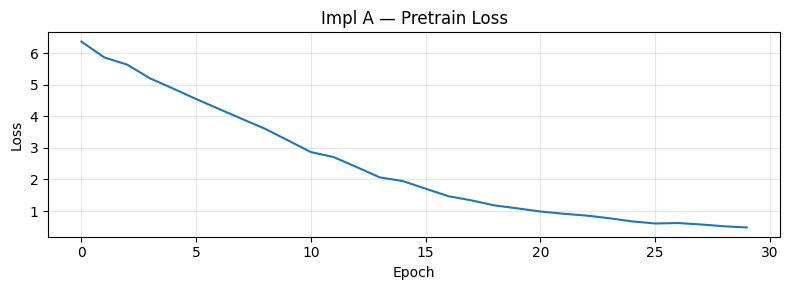

In [11]:
# ── 预训练 ──
bert_a = BERTScratch(VOCAB_SIZE, D_MODEL, NUM_HEADS, NUM_LAYERS, D_FF, MAX_SEQ_LEN, DROPOUT).to(device)
pt_model_a = BERTForPretraining(bert_a, VOCAB_SIZE).to(device)
print(f'BERT 编码器参数量: {sum(p.numel() for p in bert_a.parameters()):,}')

opt_pt = torch.optim.Adam(pt_model_a.parameters(), lr=PRETRAIN_LR)
pt_losses_a = []
for epoch in range(PRETRAIN_EPOCHS):
    loss = pretrain_epoch(pt_model_a, pretrain_loader, opt_pt, device)
    pt_losses_a.append(loss)
    if (epoch + 1) % 10 == 0:
        print(f'Pretrain Epoch [{epoch+1:3d}/{PRETRAIN_EPOCHS}]  Loss: {loss:.4f}')

plot_losses(pt_losses_a, 'Impl A — Pretrain Loss')

Finetune Epoch [  5/20]  Loss: 0.6766  Train Acc: 62.50%  Test Acc: 43.75%
Finetune Epoch [ 10/20]  Loss: 0.6588  Train Acc: 65.62%  Test Acc: 56.25%
Finetune Epoch [ 15/20]  Loss: 0.5821  Train Acc: 68.75%  Test Acc: 62.50%
Finetune Epoch [ 20/20]  Loss: 0.5042  Train Acc: 84.38%  Test Acc: 62.50%

实现 A 最终测试准确率: 62.50%


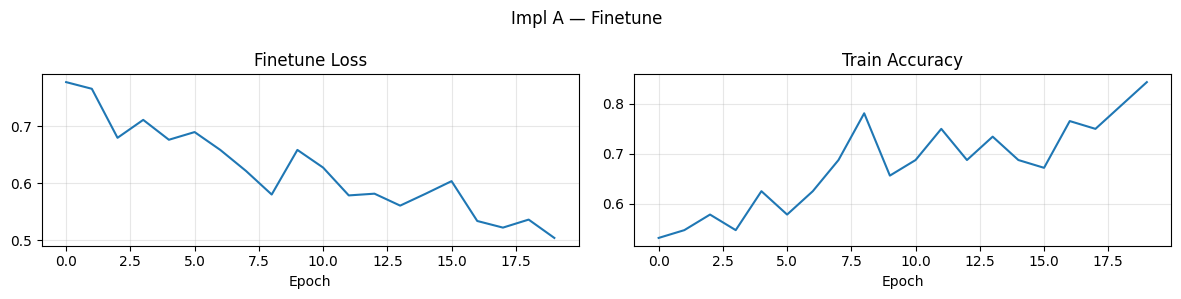

In [12]:
# ── 微调 ──
clf_a = BERTClassifier(bert_a, num_classes=2).to(device)
opt_ft = torch.optim.Adam(clf_a.parameters(), lr=FINETUNE_LR)

ft_losses_a, ft_accs_a = [], []
for epoch in range(FINETUNE_EPOCHS):
    loss, acc = finetune_epoch(clf_a, train_loader, opt_ft, device)
    ft_losses_a.append(loss)
    ft_accs_a.append(acc)
    if (epoch + 1) % 5 == 0:
        test_acc = evaluate(clf_a, test_loader, device)
        print(f'Finetune Epoch [{epoch+1:3d}/{FINETUNE_EPOCHS}]  Loss: {loss:.4f}  '
              f'Train Acc: {acc:.2%}  Test Acc: {test_acc:.2%}')

test_acc_a = evaluate(clf_a, test_loader, device)
print(f'\n实现 A 最终测试准确率: {test_acc_a:.2%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(ft_losses_a)
axes[0].set_title('Finetune Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)
axes[1].plot(ft_accs_a)
axes[1].set_title('Train Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)
plt.suptitle('Impl A — Finetune', fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. 实现 B — 简洁实现

使用 `nn.TransformerEncoder` 替代手写的 Attention + Encoder Block。

| 源代码实现 | 简洁实现 |
|---|---|
| `MultiHeadAttention` (手写 Q/K/V 投影 + 缩放点积) | `nn.TransformerEncoderLayer` 内置 |
| `TransformerBlock` (手写 Add&Norm + FFN) | `nn.TransformerEncoderLayer` 内置 |
| `BERTScratch` (手写 N 层堆叠) | `nn.TransformerEncoder(layer, N)` |
| `BERTEmbedding` | 相同（无高层 API） |
| 任务头 | 相同 |

In [13]:
class BERTConcise(nn.Module):
    """简洁 BERT：nn.TransformerEncoder 替代手写编码器"""

    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, dropout):
        super().__init__()
        self.d_model = d_model
        self.embedding = BERTEmbedding(vocab_size, d_model, max_len, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=d_ff,
            dropout=dropout, activation='gelu', batch_first=True,  # batch_first=True!
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def encode(self, input_ids, segment_ids, attention_mask):
        x = self.embedding(input_ids, segment_ids)   # (B, S, d)
        # PyTorch: True = 忽略该位置（与 BERT 惯例相反）
        padding_mask = (attention_mask == 0)
        x = self.encoder(x, src_key_padding_mask=padding_mask)  # (B, S, d)
        return x

In [14]:
# ── 预训练 B ──
bert_b = BERTConcise(VOCAB_SIZE, D_MODEL, NUM_HEADS, NUM_LAYERS, D_FF, MAX_SEQ_LEN, DROPOUT).to(device)
pt_model_b = BERTForPretraining(bert_b, VOCAB_SIZE).to(device)
print(f'BERT (简洁) 编码器参数量: {sum(p.numel() for p in bert_b.parameters()):,}')

opt_pt_b = torch.optim.Adam(pt_model_b.parameters(), lr=PRETRAIN_LR)
pt_losses_b = []
for epoch in range(PRETRAIN_EPOCHS):
    loss = pretrain_epoch(pt_model_b, pretrain_loader, opt_pt_b, device)
    pt_losses_b.append(loss)
    if (epoch + 1) % 10 == 0:
        print(f'Pretrain Epoch [{epoch+1:3d}/{PRETRAIN_EPOCHS}]  Loss: {loss:.4f}')

# ── 微调 B ──
clf_b = BERTClassifier(bert_b, num_classes=2).to(device)
opt_ft_b = torch.optim.Adam(clf_b.parameters(), lr=FINETUNE_LR)

ft_losses_b, ft_accs_b = [], []
for epoch in range(FINETUNE_EPOCHS):
    loss, acc = finetune_epoch(clf_b, train_loader, opt_ft_b, device)
    ft_losses_b.append(loss)
    ft_accs_b.append(acc)
    if (epoch + 1) % 5 == 0:
        test_acc = evaluate(clf_b, test_loader, device)
        print(f'Finetune Epoch [{epoch+1:3d}/{FINETUNE_EPOCHS}]  Loss: {loss:.4f}  '
              f'Train Acc: {acc:.2%}  Test Acc: {test_acc:.2%}')

test_acc_b = evaluate(clf_b, test_loader, device)
print(f'\n实现 B 最终测试准确率: {test_acc_b:.2%}')

BERT (简洁) 编码器参数量: 332,032
Pretrain Epoch [ 10/30]  Loss: 3.2620
Pretrain Epoch [ 20/30]  Loss: 1.1674
Pretrain Epoch [ 30/30]  Loss: 0.5678


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Finetune Epoch [  5/20]  Loss: 0.6884  Train Acc: 57.81%  Test Acc: 68.75%
Finetune Epoch [ 10/20]  Loss: 0.6359  Train Acc: 59.38%  Test Acc: 50.00%
Finetune Epoch [ 15/20]  Loss: 0.5774  Train Acc: 73.44%  Test Acc: 56.25%
Finetune Epoch [ 20/20]  Loss: 0.5683  Train Acc: 76.56%  Test Acc: 50.00%

实现 B 最终测试准确率: 50.00%


---

## 5. 结果对比

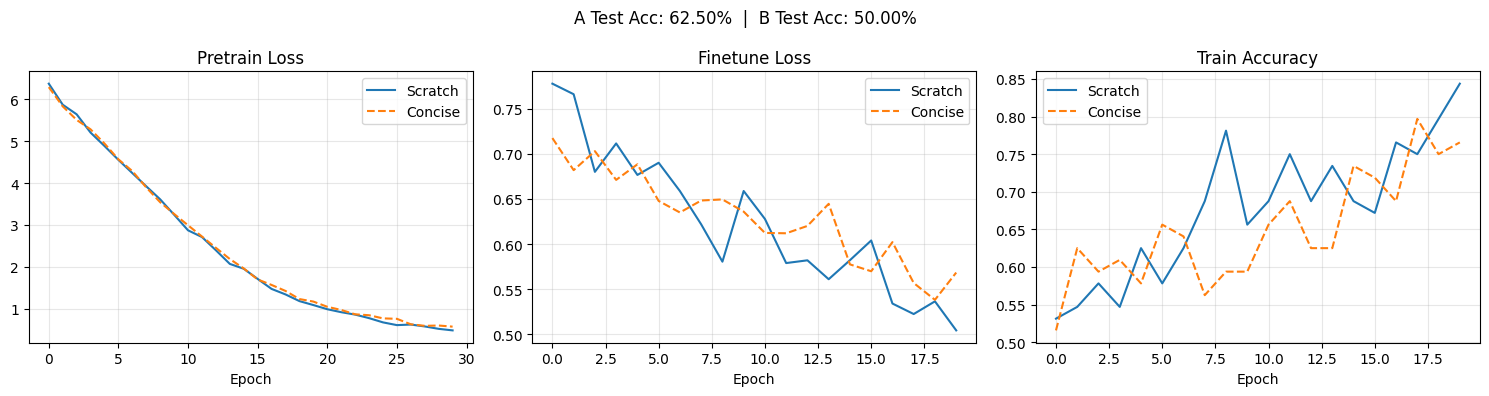

两种实现架构等价，结果差异来自随机初始化和 nn.TransformerEncoder 内部 dropout 位置的细微差别。


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 预训练损失
axes[0].plot(pt_losses_a, label='Scratch')
axes[0].plot(pt_losses_b, '--', label='Concise')
axes[0].set_title('Pretrain Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 微调损失
axes[1].plot(ft_losses_a, label='Scratch')
axes[1].plot(ft_losses_b, '--', label='Concise')
axes[1].set_title('Finetune Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 微调准确率
axes[2].plot(ft_accs_a, label='Scratch')
axes[2].plot(ft_accs_b, '--', label='Concise')
axes[2].set_title('Train Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'A Test Acc: {test_acc_a:.2%}  |  B Test Acc: {test_acc_b:.2%}', fontsize=12)
plt.tight_layout()
plt.show()
print('两种实现架构等价，结果差异来自随机初始化和 nn.TransformerEncoder 内部 dropout 位置的细微差别。')

---

## 附录 A：注意力权重可视化

使用实现 A 的手写注意力，展示最后一层各注意力头的完整注意力矩阵（每个 token 对其他 token 的关注分布）。

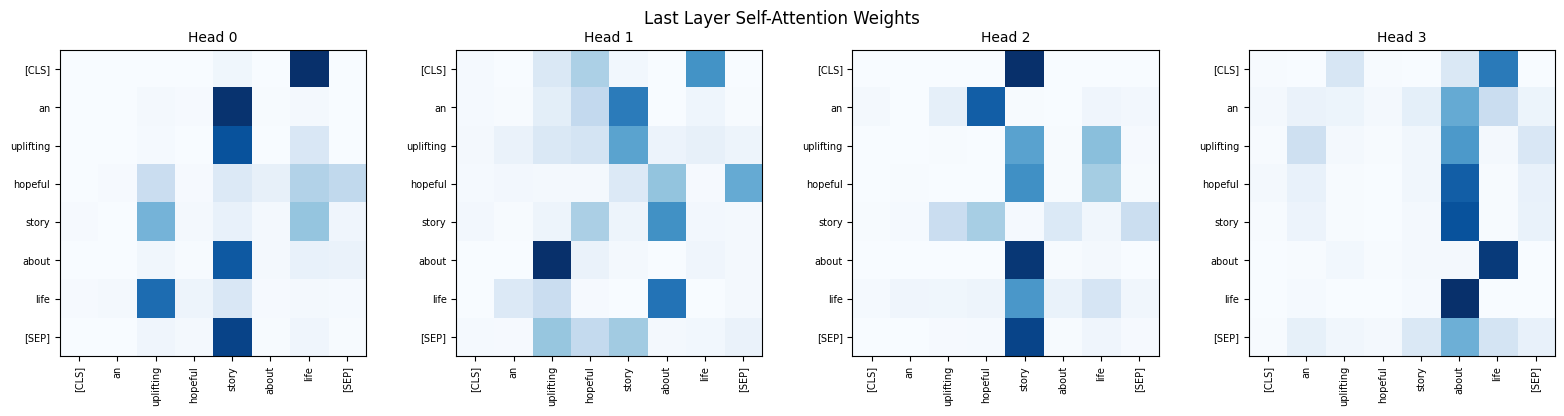

In [16]:
# 取一条测试样本
clf_a.eval()
sample = test_ds[0]
ids  = sample['input_ids'].unsqueeze(0).to(device)
segs = sample['segment_ids'].unsqueeze(0).to(device)
mask = sample['attention_mask'].unsqueeze(0).to(device)

with torch.no_grad():
    _ = clf_a(ids, segs, mask)

# 获取最后一层的注意力权重
attn = bert_a._attn_weights[-1][0].cpu()  # (heads, S, S)
seq_len_actual = mask[0].sum().item()

# 解码 token 用于标注
token_ids = ids[0, :seq_len_actual].cpu().tolist()
tokens = [tokenizer.idx2word.get(t, '?') for t in token_ids]

fig, axes = plt.subplots(1, NUM_HEADS, figsize=(4 * NUM_HEADS, 4))
for h in range(NUM_HEADS):
    ax = axes[h] if NUM_HEADS > 1 else axes
    im = ax.imshow(attn[h, :seq_len_actual, :seq_len_actual].numpy(), cmap='Blues')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f'Head {h}', fontsize=10)
plt.suptitle('Last Layer Self-Attention Weights', fontsize=12)
plt.tight_layout()
plt.show()

---

## 附录 B：面试拓展

### 高频面试题

**Q1: BERT 为什么使用 MLM 而不是自回归语言模型？**

- 自回归模型（GPT）只能单向预测（从左到右），无法同时利用左右上下文
- MLM 通过遮盖部分 token，让模型从**双向上下文**中预测，学到更丰富的语义表示
- 代价：MLM 每次只预测 15% 的 token，训练效率低于自回归模型（自回归预测所有 token）
- 适用场景不同：MLM 适合**理解任务**（分类、QA），自回归适合**生成任务**

**Q2: MLM 的 80-10-10 遮盖策略有什么作用？**

- 80% `[MASK]`：主要的训练信号
- 10% 随机词：防止模型认为只有 `[MASK]` 位置需要预测，增强泛化
- 10% 保持原词：缩小预训练与微调的分布差距（微调时没有 `[MASK]`）
- 如果 100% 用 `[MASK]`，模型会过度依赖这个特殊标记，泛化到下游任务时性能下降

**Q3: NSP 任务的争议是什么？后续模型如何改进？**

- NSP 原意是学习句间关系，提升 QA/NLI 任务
- **RoBERTa** 发现去掉 NSP 后性能不降反升，原因是随机负样本太容易区分（主题差异已足够，模型学到的是主题而非逻辑关系）
- **ALBERT** 用 SOP (Sentence Order Prediction) 替代：正样本是顺序句对，负样本是反序句对，迫使模型学习**顺序**而非**主题**
- 当前主流做法：大多数后续模型省略 NSP

**Q4: 为什么 BERT 用学习的位置编码而非固定三角函数？**

- 固定三角函数（Transformer 原始论文）具有外推能力，但表达力受限
- 学习的位置编码可以在训练中自动优化，更灵活
- BERT 的最大长度固定为 512，不需要外推，因此学习编码更合适
- 现代模型（如 LLaMA）转向 RoPE（旋转位置编码），兼顾灵活性和外推能力

**Q5: `[CLS]` token 为什么能代表整个序列？**

- `[CLS]` 没有对应的实际词义，不受 MLM 预测目标的偏向
- 经过多层 Self-Attention，`[CLS]` 聚合了所有位置的信息
- NSP 任务用 `[CLS]` 做二分类，进一步强化其全局表示能力
- 微调时加监督信号，使 `[CLS]` 表示适配具体任务

**Q6: BERT 预训练与微调的参数更新有什么不同？**

- 预训练：所有参数从头训练（大数据、大算力），使用 MLM + NSP 损失
- 微调：**全部参数**继续更新（编码器 + 新添加的任务头），但用更小的学习率（2e-5 ~ 5e-5）
- 微调时 BERT 编码器已有良好初始化，只需少量数据和 epoch 即可收敛
- 变体：冻结部分层（Feature-based）、LoRA 等参数高效微调方法

**Q7: BERT vs GPT vs ELMo 的核心区别？**

| 维度 | ELMo | GPT | BERT |
|------|------|-----|------|
| 架构 | 双向 LSTM 拼接 | 单向 Transformer Decoder | 双向 Transformer Encoder |
| 双向性 | 浅层拼接（前向 + 后向独立） | 单向（从左到右） | 深度双向（每层双向交互） |
| 预训练 | 语言模型 | 自回归语言模型 | MLM + NSP |
| 微调 | Feature-based（冻结特征） | Fine-tuning | Fine-tuning |
| 适合任务 | 通用特征提取 | 生成任务 | 理解任务 |

**Q8: BERT 的局限性？**

- **预训练-微调不一致**：预训练有 `[MASK]`，微调/推理没有
- **最大长度限制**：固定 512 token，处理长文档困难
- **不适合生成**：双向编码器无法自回归生成文本
- **训练成本高**：大规模预训练需要大量 GPU 资源
- 后续改进：XLNet（排列语言模型）、Longformer（长序列）、T5（统一生成框架）

### 进阶探索方向

- **RoBERTa**: 去掉 NSP、动态 MLM、更大 batch size 和更多数据，显著提升性能
- **ALBERT**: 参数共享 + SOP 替代 NSP，大幅减少参数量
- **DistilBERT**: 知识蒸馏压缩模型，保留 97% 性能但减少 40% 参数
- **ELECTRA**: 用判别式预训练（替换检测）替代 MLM，训练效率更高